Querying BigQuery: tpu-pytorch.benchmark_dataset_test.torchprime-e2e-tests
Date range: 2025-05-29 17:52:00 America/Los_Angeles to 2025-06-03 20:00:00 America/Los_Angeles
Retrieved 1026 rows



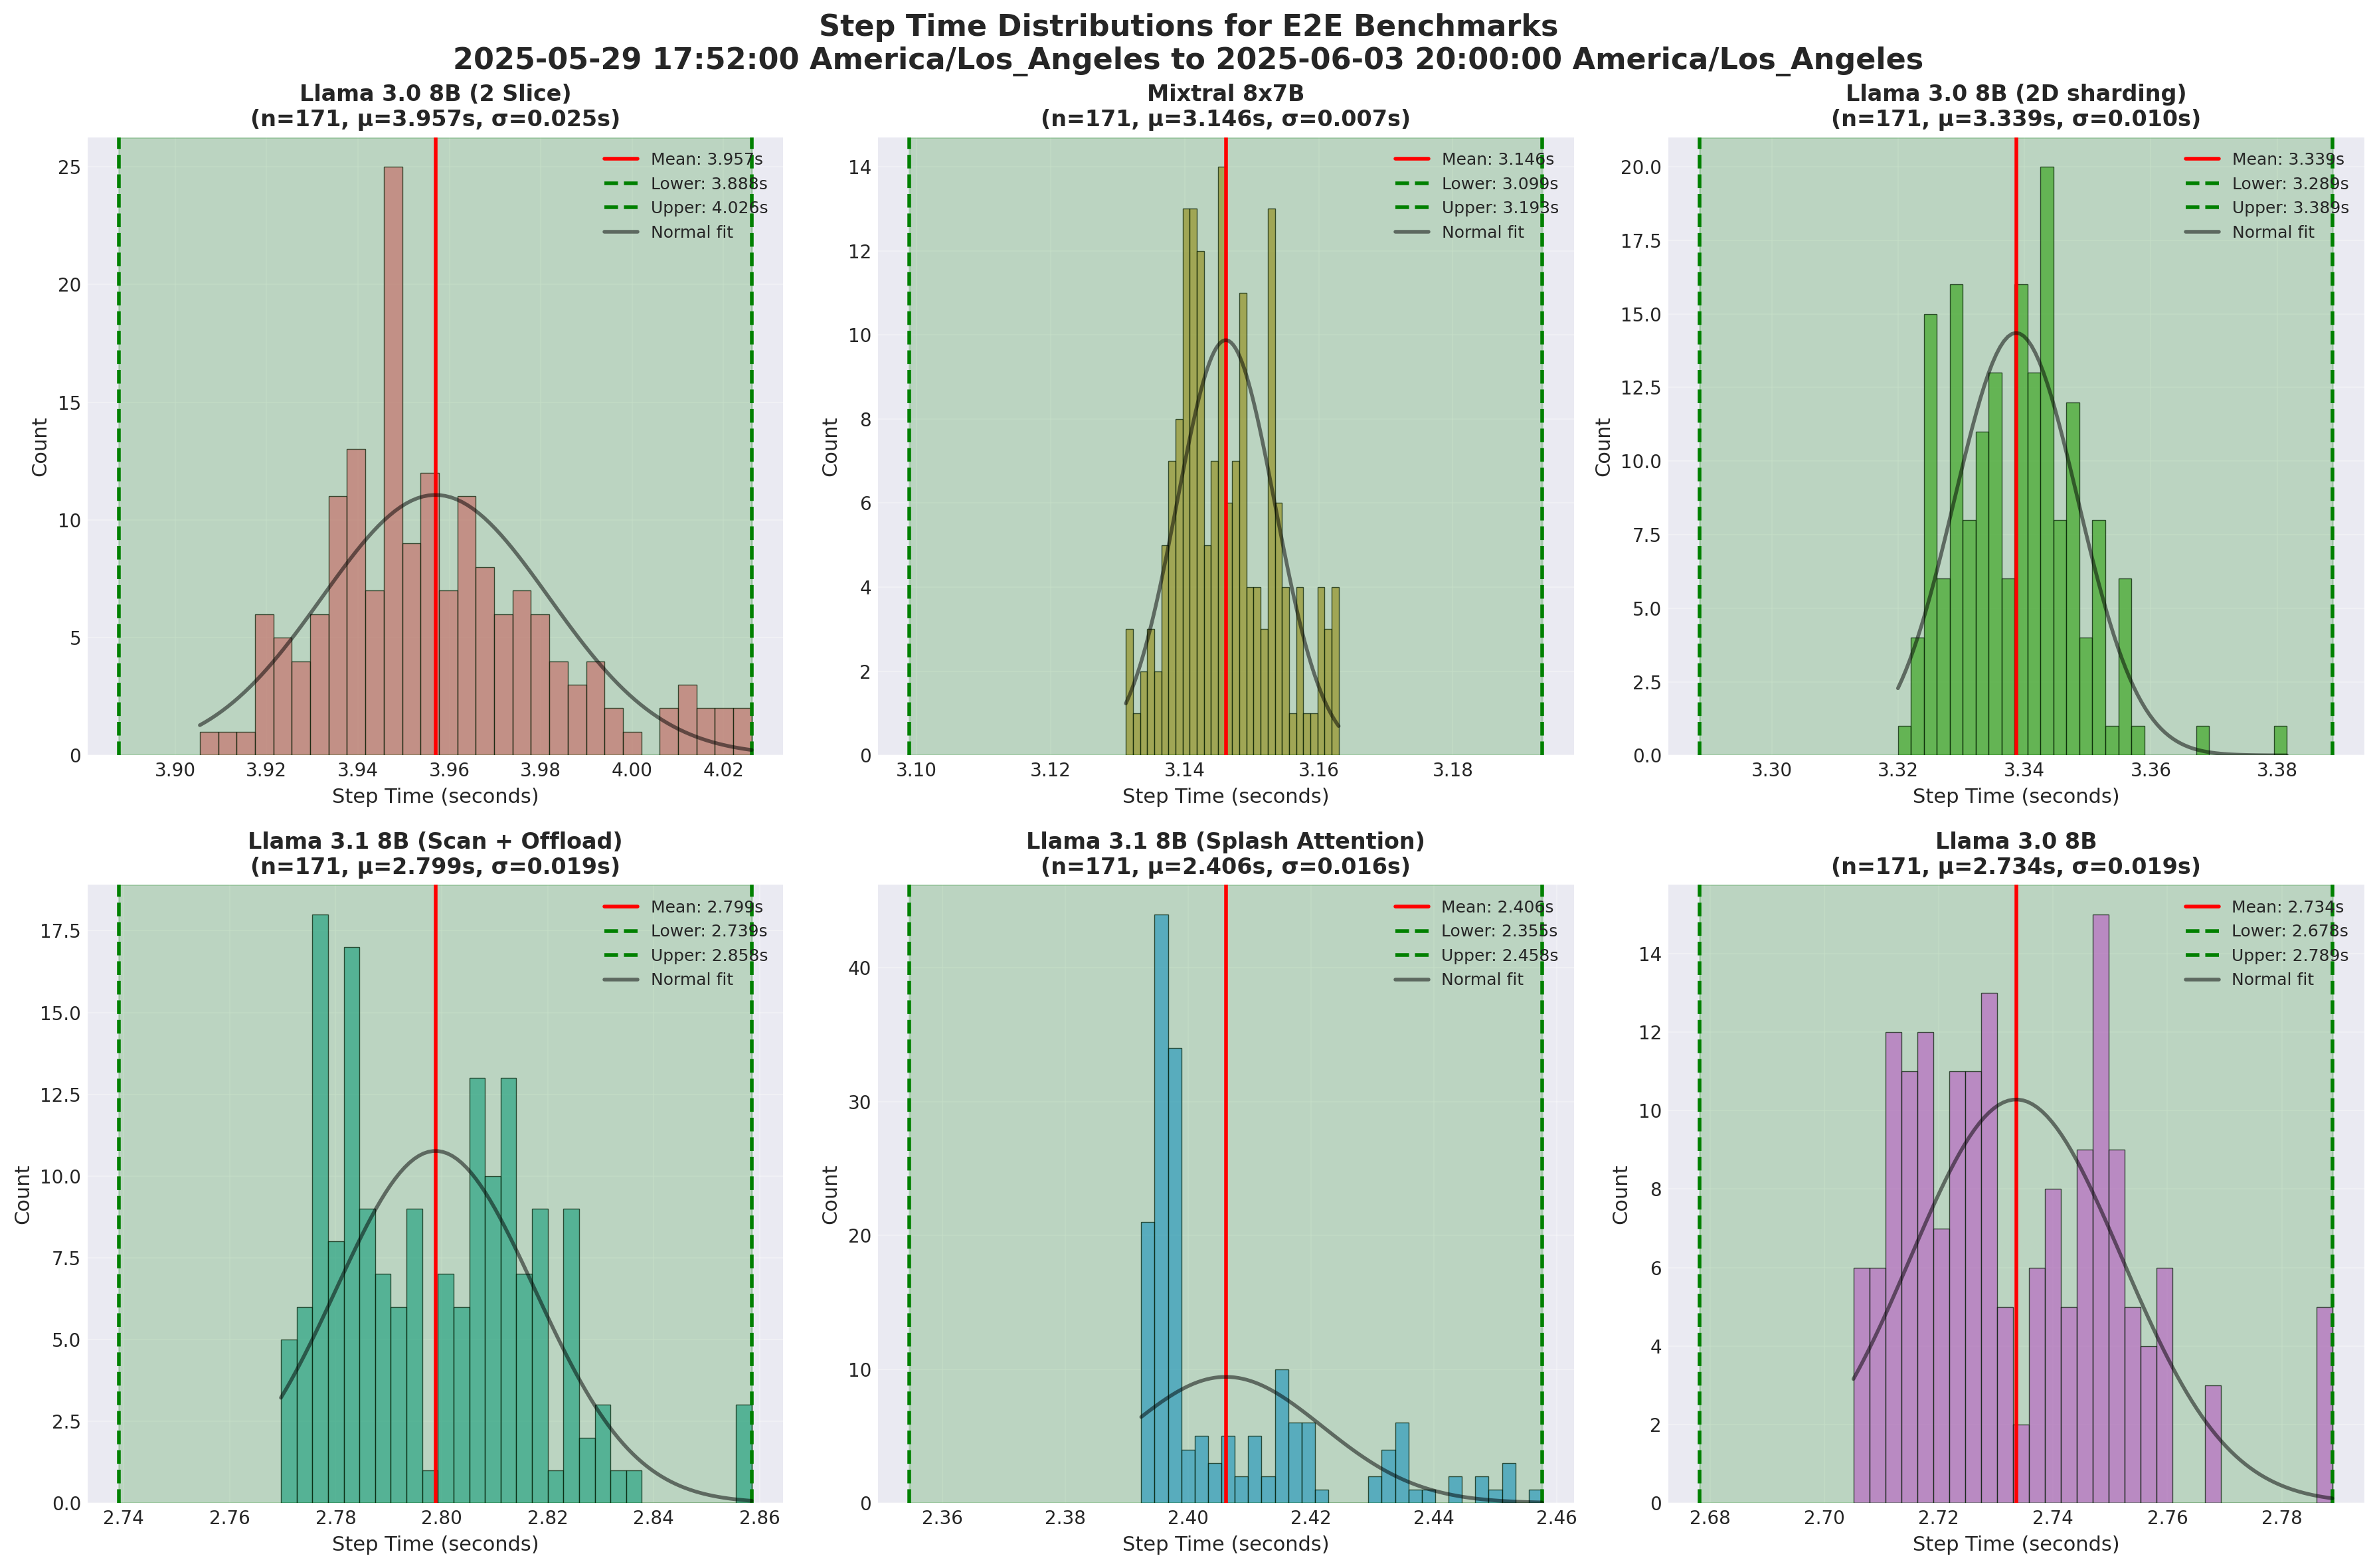


Summary Statistics:


,Benchmark,Count,Mean (s),Std (s),Min (s),Max (s),Lower Bound (s),Upper Bound (s),Range (ms)
0,Llama 3.0 8B (2 Slice),171,3.9570,0.0248,3.9054,4.0262,3.8878,4.0262,138.3873
1,Mixtral 8x7B,171,3.1461,0.0073,3.1312,3.1630,3.0989,3.1933,94.3842
2,Llama 3.0 8B (2D sharding),171,3.3387,0.0098,3.3200,3.3815,3.2886,3.3887,100.1601
3,Llama 3.1 8B (Scan + Offload),171,2.7988,0.0188,2.7697,2.8585,2.7392,2.8585,119.3307
4,Llama 3.1 8B (Splash Attention),171,2.4061,0.0157,2.3923,2.4576,2.3546,2.4576,102.9958
5,Llama 3.0 8B,171,2.7335,0.0185,2.7051,2.7889,2.6782,2.7889,110.6845


/tmp/ipykernel_1609336/865764064.py:253: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_for_boxplot, labels=labels_for_boxplot, patch_artist=True) # type: ignore


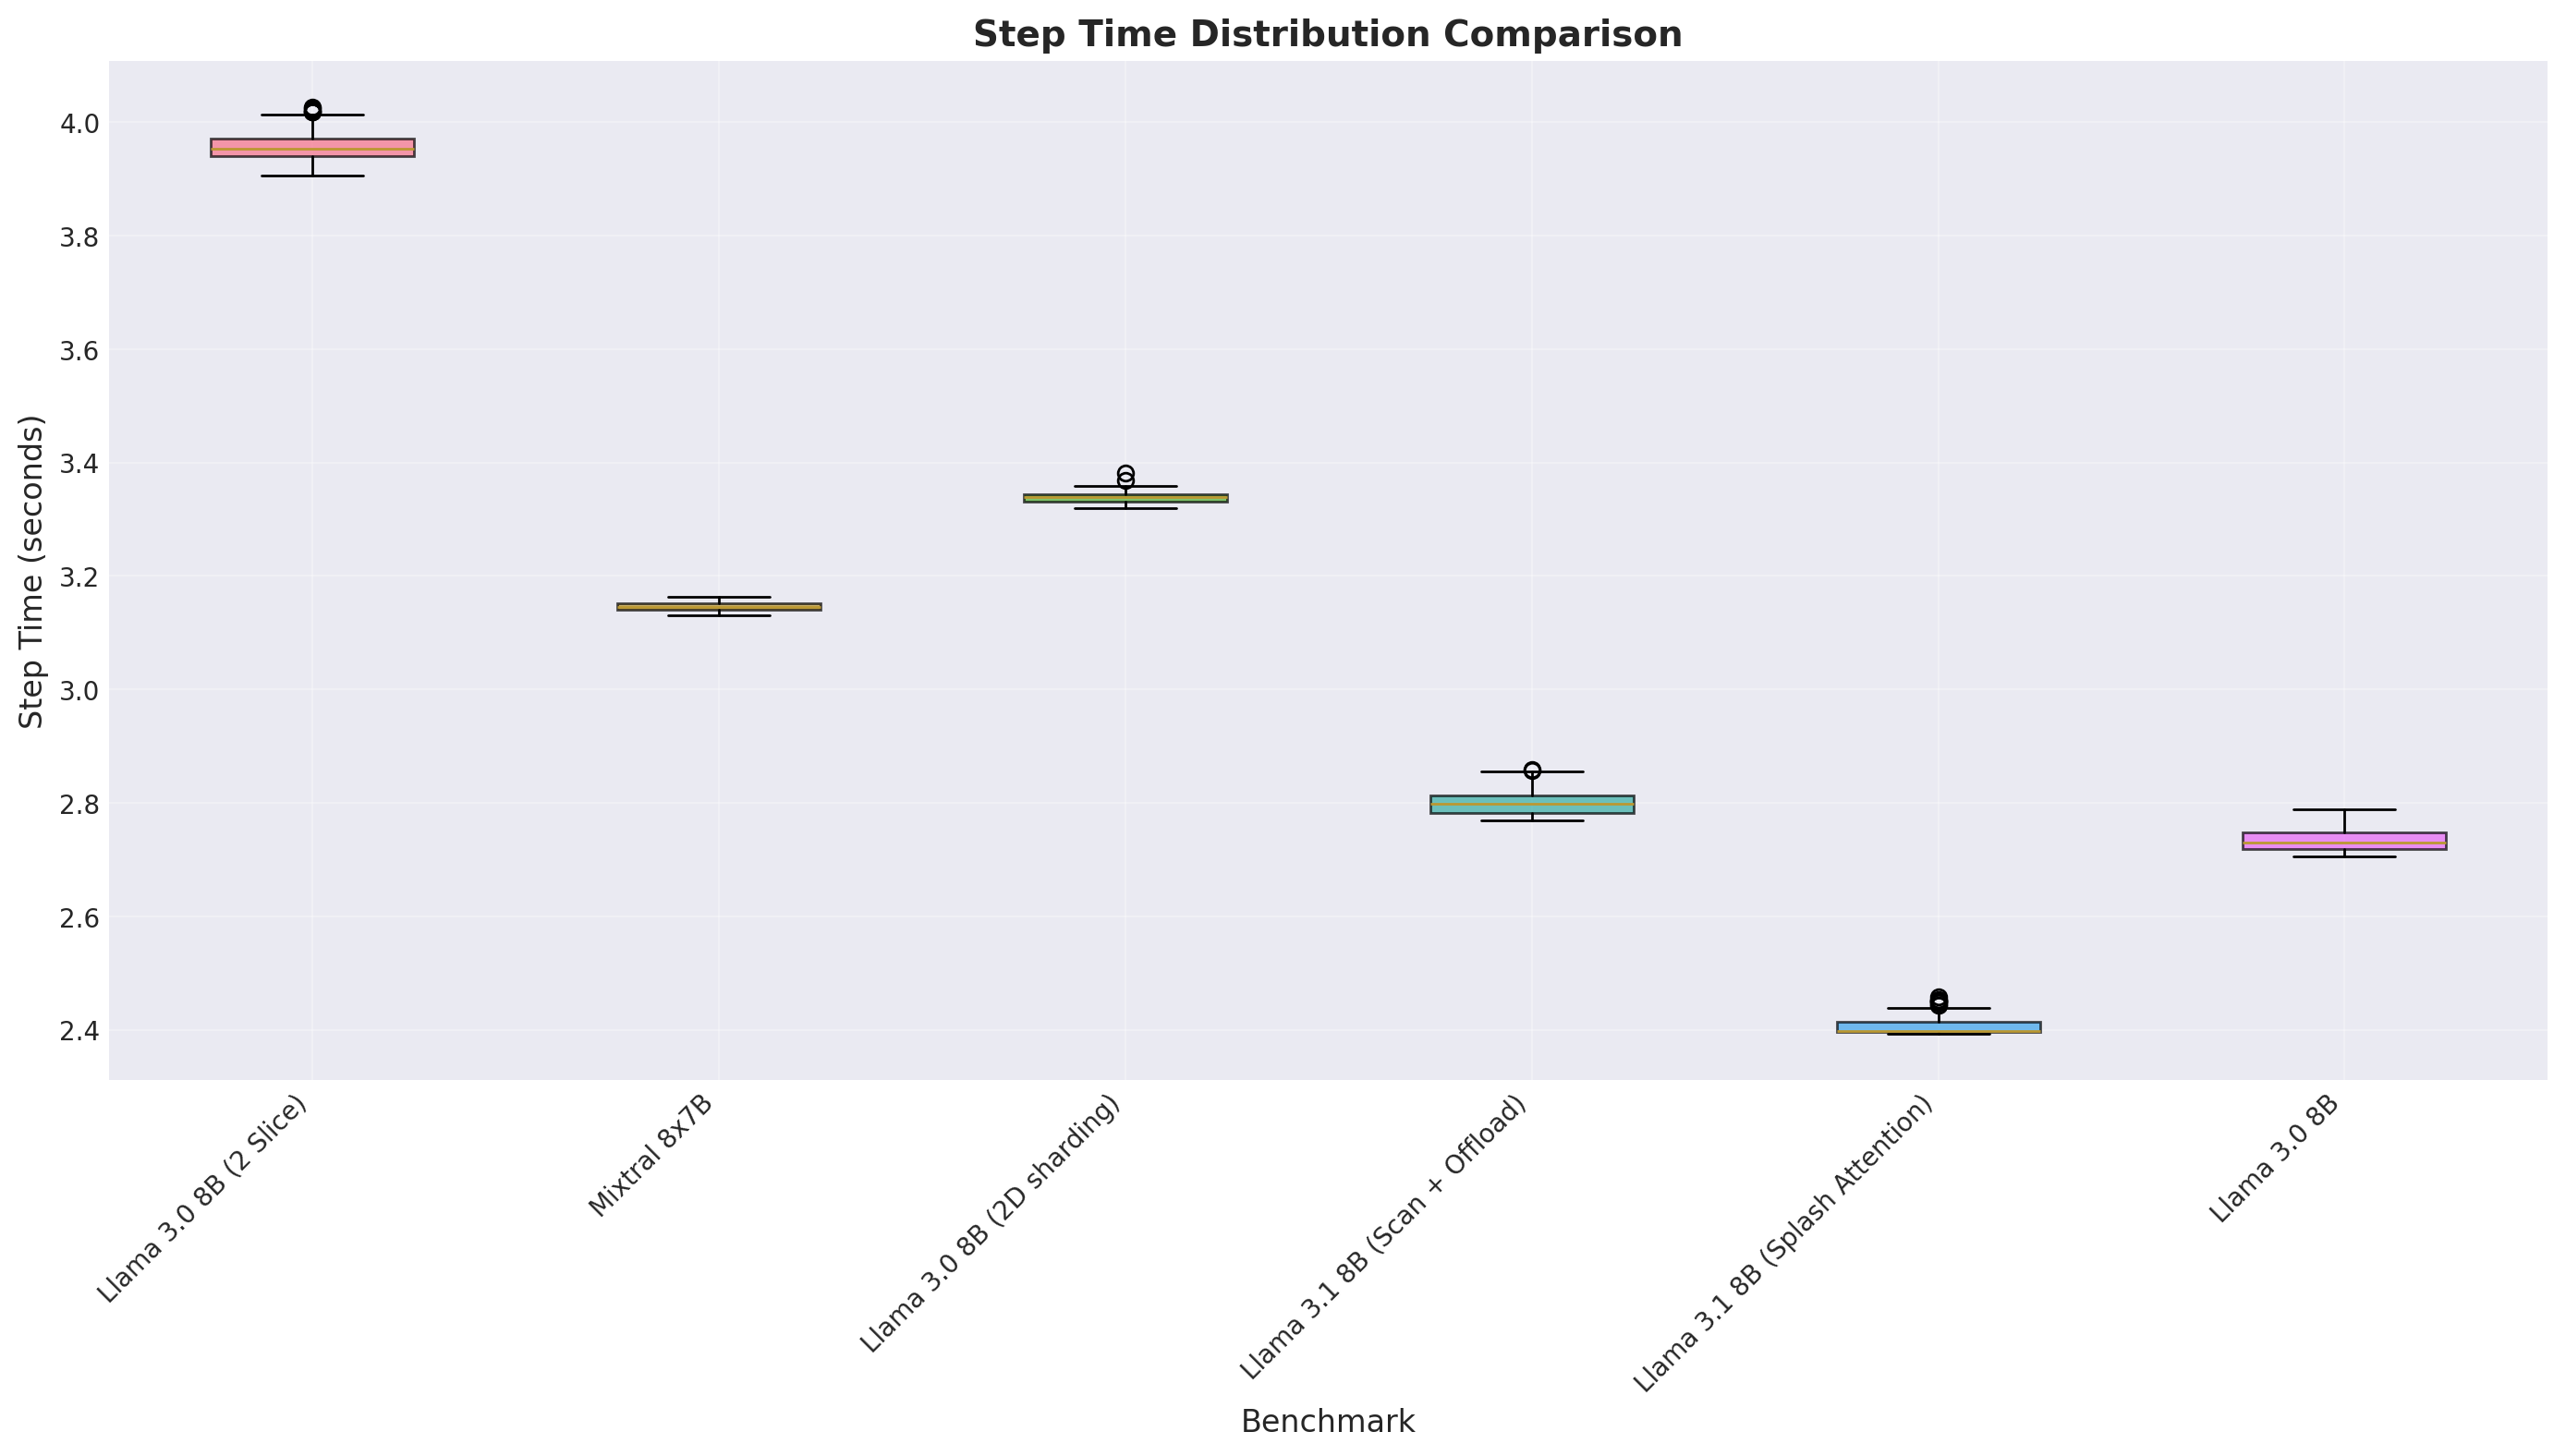

In [2]:
"""
Query BigQuery for E2E test results and create step time histogram plots for all benchmarks.
"""

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
from google.cloud import bigquery
from IPython.display import display

# Enable retina mode for high-quality plots
%config InlineBackend.figure_format = 'retina'

# Set a nice theme
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuration
TORCHPRIME_SOFTWARE_ID = "pytorch_torchprime"  # Update this if needed
BQ_PROJECT = "tpu-pytorch"
BQ_DATASET = "benchmark_dataset_test"
BQ_TABLE = "torchprime-e2e-tests"
START_TIME = "2025-05-29 17:52:00 America/Los_Angeles"
END_TIME = "2025-06-03 20:00:00 America/Los_Angeles"
LIMIT = 1200
CONFIDENCE_LEVEL = 0.999

# Benchmark definitions
def match_llama3_8b(row):
    config = json.loads(row.configs_framework)
    return (
        row.run_id.startswith("llama-3-8b-")
        and config["dcn_mesh"]["fsdp"] == 1
        and config["ici_mesh"]["tensor"] == 1
    )

def match_llama3_1_8b_sa(row):
    config = json.loads(row.configs_framework)
    return (
        row.run_id.startswith("llama-3dot1-8b-sa")
        and config["model"]["attention_kernel"] == "splash_attention"
    )

def match_llama3_1_8b_scan_offload(row):
    config = json.loads(row.configs_framework)
    return (
        row.run_id.startswith("llama-3dot1-8b-")
        and config["model"]["remat"]["scan_layers"] == "model.layers"
        and config["dcn_mesh"]["fsdp"] == 1
        and config["ici_mesh"]["tensor"] == 1
    )

def match_llama3_8b_2d(row):
    config = json.loads(row.configs_framework)
    return (
        row.run_id.startswith("llama-3-8b-2d")
        and config["dcn_mesh"]["fsdp"] == 1
        and config["ici_mesh"]["fsdp"] == 2
        and config["ici_mesh"]["tensor"] == 2
    )

def match_mixtral(row):
    config = json.loads(row.configs_framework)
    return row.run_id.startswith("mixtral-8x7b-") and config["ici_mesh"]["fsdp"] == 4

def match_llama_3_8b_2_slice(row):
    config = json.loads(row.configs_framework)
    return (
        row.run_id.startswith("llama-3-8b-2-slice")
        and config["dcn_mesh"]["fsdp"] == 2
        and config["ici_mesh"]["fsdp"] == 4
    )

BENCHMARKS = {
    "Llama 3.0 8B": match_llama3_8b,
    "Llama 3.1 8B (Splash Attention)": match_llama3_1_8b_sa,
    "Llama 3.1 8B (Scan + Offload)": match_llama3_1_8b_scan_offload,
    "Llama 3.0 8B (2D sharding)": match_llama3_8b_2d,
    "Mixtral 8x7B": match_mixtral,
    "Llama 3.0 8B (2 Slice)": match_llama_3_8b_2_slice,
}

# Query BigQuery
print(f"Querying BigQuery: {BQ_PROJECT}.{BQ_DATASET}.{BQ_TABLE}")
print(f"Date range: {START_TIME} to {END_TIME}")

client = bigquery.Client()

query = f"""
SELECT
  *
FROM
  `{BQ_PROJECT}`.`{BQ_DATASET}`.`{BQ_TABLE}`
WHERE
  software_id = '{TORCHPRIME_SOFTWARE_ID}' AND
  update_timestamp >= TIMESTAMP('{START_TIME}') AND
  update_timestamp <= TIMESTAMP('{END_TIME}')
ORDER BY
  update_timestamp DESC
LIMIT
  {LIMIT};
"""

query_job = client.query(query)
rows = list(query_job.result())
print(f"Retrieved {len(rows)} rows\n")

# Group rows by benchmark
step_time_by_benchmark = {}

for row in rows:
    matched = set()
    for name, match_fn in BENCHMARKS.items():
        if match_fn(row):
            matched.add(name)
    
    if not matched:
        continue
    
    if len(matched) > 1:
        print(f"Warning: Run ID {row.run_id} matches multiple benchmarks: {matched}")
        continue
    
    step_time_by_benchmark.setdefault(matched.pop(), []).append(row.metrics_step_time)

# Compute bounds function
def calculate_confidence_t_interval(alpha, stdev, count):
    if count <= 1 or stdev < 0:
        return np.nan
    if stdev == 0:
        return 0.0
    
    df = count - 1
    confidence_level = 1 - alpha
    sem = stdev / np.sqrt(count)
    _, upper_bound = scipy.stats.t.interval(confidence_level, df, loc=0, scale=sem)
    return upper_bound

def compute_bounds(step_times, confidence_level=CONFIDENCE_LEVEL):
    n = len(step_times)
    if n <= 1:
        return None, None
    
    mean = sum(step_times) / n
    min_time = min(step_times)
    max_time = max(step_times)
    
    stdev = np.std(step_times, ddof=1)  # Sample standard deviation
    t_critical = calculate_confidence_t_interval(1 - confidence_level, stdev, n)
    
    # Calculate the half-width H
    H = max(
        t_critical,
        0.015 * mean,
        max_time - mean,
        mean - min_time,
    )
    
    lower_bound = max(0, mean - H)
    upper_bound = mean + H
    
    return lower_bound, upper_bound

# Create histogram plots
n_benchmarks = len(BENCHMARKS)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, step_times) in enumerate(step_time_by_benchmark.items()):
    ax = axes[idx]
    
    if len(step_times) <= 1:
        ax.text(0.5, 0.5, f'{name}\nInsufficient data', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    
    # Compute statistics
    mean = np.mean(step_times)
    std = np.std(step_times, ddof=1)
    lower_bound, upper_bound = compute_bounds(step_times)
    
    # Create histogram
    n_bins = min(30, max(10, len(step_times) // 5))
    counts, bins, patches = ax.hist(step_times, bins=n_bins, alpha=0.7, 
                                   color=sns.color_palette()[idx % len(sns.color_palette())],
                                   edgecolor='black', linewidth=0.5)
    
    # Add vertical lines for mean and bounds
    ax.axvline(mean, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean:.3f}s')
    ax.axvline(lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower: {lower_bound:.3f}s')
    ax.axvline(upper_bound, color='green', linestyle='--', linewidth=2, label=f'Upper: {upper_bound:.3f}s')
    
    # Add shaded region for confidence interval
    ax.axvspan(lower_bound, upper_bound, alpha=0.2, color='green')
    
    # Add normal distribution overlay
    x = np.linspace(min(step_times), max(step_times), 100)
    normal_dist = scipy.stats.norm(loc=mean, scale=std)
    y = normal_dist.pdf(x) * len(step_times) * (bins[1] - bins[0])
    ax.plot(x, y, 'k-', linewidth=2, alpha=0.5, label='Normal fit')
    
    # Styling
    ax.set_xlabel('Step Time (seconds)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{name}\n(n={len(step_times)}, μ={mean:.3f}s, σ={std:.3f}s)', 
                fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

# Remove empty subplots
for idx in range(n_benchmarks, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle(f'Step Time Distributions for E2E Benchmarks\n{START_TIME} to {END_TIME}', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Display summary statistics
summary_data = []
for name, step_times in step_time_by_benchmark.items():
    if len(step_times) > 1:
        lower_bound, upper_bound = compute_bounds(step_times)
        summary_data.append({
            'Benchmark': name,
            'Count': len(step_times),
            'Mean (s)': np.mean(step_times),
            'Std (s)': np.std(step_times, ddof=1),
            'Min (s)': min(step_times),
            'Max (s)': max(step_times),
            'Lower Bound (s)': lower_bound,
            'Upper Bound (s)': upper_bound,
            'Range (ms)': (upper_bound - lower_bound) * 1000
        })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.round(4)

print("\nSummary Statistics:")
display(summary_df)

# Create a box plot for comparison
plt.figure(figsize=(14, 8))
data_for_boxplot = [step_times for name, step_times in step_time_by_benchmark.items() if len(step_times) > 1]
labels_for_boxplot = [name for name, step_times in step_time_by_benchmark.items() if len(step_times) > 1]

bp = plt.boxplot(data_for_boxplot, labels=labels_for_boxplot, patch_artist=True) # type: ignore

# Color the boxes
colors = sns.color_palette(n_colors=len(bp['boxes']))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.xlabel('Benchmark', fontsize=12)
plt.ylabel('Step Time (seconds)', fontsize=12)
plt.title('Step Time Distribution Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()